# Medical Insurance Cost Prediction using Linear Regression

## What does this project do?
This project builds machine learning models that **predict how much a person's medical insurance will cost** (the `charges` column) using simple information such as age, BMI, smoking status, number of children, sex and region.

## What is the target variable?
The **target variable** is `charges` – the individual medical cost billed by the health insurance company. Because it is a continuous number (for example, 3,500 or 42,000), this is a **regression** problem.

## Why is Linear Regression suitable here?
- The target is a **number**, not a category.
- The input features are a mix of simple numeric and categorical columns, which are easy to encode.
- Linear Regression is **fast, simple and easy to interpret** – each feature gets a coefficient that tells us how it pushes the prediction up or down.
- It gives us a strong **baseline** before trying more complex models.

We will compare three linear models: **Linear Regression**, **Ridge Regression** and **Lasso Regression**, and use **cross-validation** and **hyperparameter tuning** to pick the best one.

**Workflow:** Data Collection → EDA → Preprocessing → Train/Test Split → Linear Regression → Ridge → Lasso → Hyperparameter Tuning → Cross Validation → Model Comparison → Final Evaluation

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 3. Load Dataset
The dataset is the **Medical Cost Personal Dataset** from Kaggle. To avoid any Kaggle login or API key, we read the same `insurance.csv` file directly from a **public raw CSV URL** (a GitHub mirror). Nothing needs to be downloaded manually.

In [2]:
URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(URL)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 4. Dataset Understanding

| Column     | Meaning |
|------------|---------|
| `age`      | age of the person |
| `sex`      | gender |
| `bmi`      | body mass index |
| `children` | number of children covered by insurance |
| `smoker`   | smoking status (yes / no) |
| `region`   | residential region in the US |
| `charges`  | medical insurance cost (**target**) |

In machine learning notation:

- `X` = the **input features** (`age`, `sex`, `bmi`, `children`, `smoker`, `region`)
- `y` = the **target** (`charges`)

The model learns a relationship between `X` and `y` so it can predict `charges` for new people.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Dataset shape

In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 1338, Columns: 7


### 5.2 Missing values

In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### 5.3 Descriptive statistics

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 5.4 Target distribution

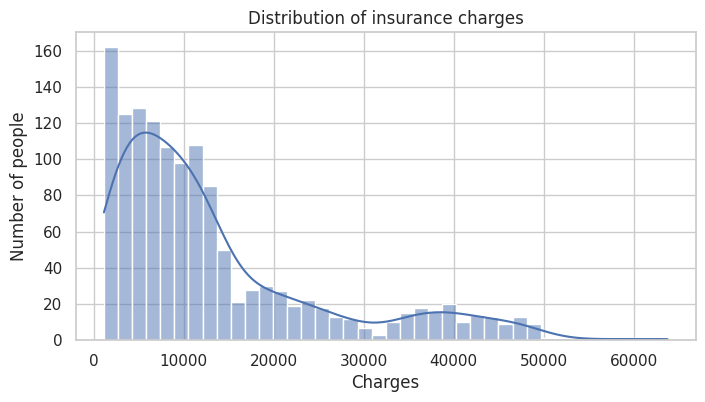

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["charges"], bins=40, kde=True)
plt.title("Distribution of insurance charges")
plt.xlabel("Charges")
plt.ylabel("Number of people")
plt.show()

### 5.5 Important relationships

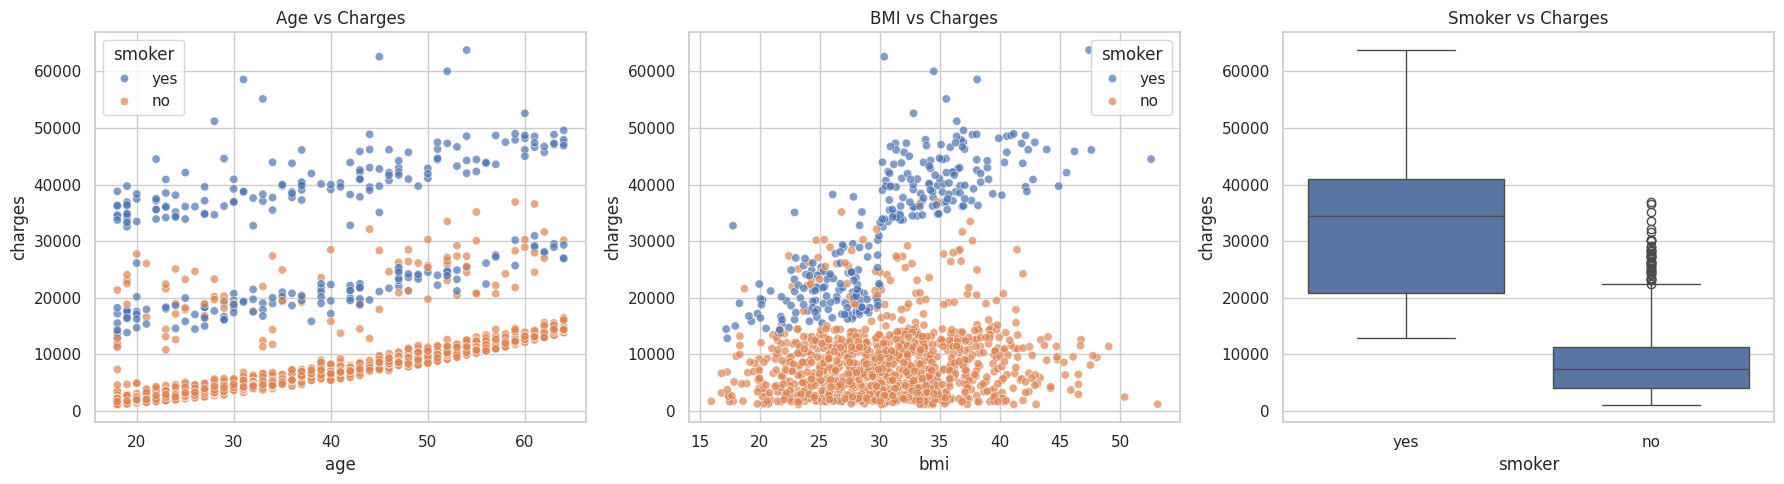

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age vs Charges
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("Age vs Charges")

# 2. BMI vs Charges
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1])
axes[1].set_title("BMI vs Charges")

# 3. Smoker vs Charges
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[2])
axes[2].set_title("Smoker vs Charges")

plt.tight_layout()
plt.show()

### What to look for in these plots
- **Age vs Charges:** charges tend to rise as age increases, and the points form visible bands rather than one single cloud.
- **BMI vs Charges:** the relationship with BMI is weaker overall, but the colours let us check whether smokers with a high BMI stand out.
- **Smoker vs Charges:** compare the boxes – smoking status usually separates the charges very clearly, so it is expected to be one of the most influential features.
- **Target distribution:** the histogram is not symmetric – it is right-skewed, with a long tail of expensive cases. Linear models can be sensitive to this, which is why a log transformation is listed under *Future Improvements*.

## 6. Data Preprocessing
We separate the features from the target and group the columns by type:

- **Numerical:** `age`, `bmi`, `children` → fill missing values (`SimpleImputer`) and scale (`StandardScaler`)
- **Categorical:** `sex`, `smoker`, `region` → convert to 0/1 columns with `OneHotEncoder(handle_unknown="ignore")`

**Why is preprocessing necessary?**
- Machine learning models only understand numbers, so text columns must be encoded.
- Ridge and Lasso penalize the size of coefficients, so features must be on a **similar scale**, otherwise the penalty treats them unfairly.
- Handling missing values prevents errors.

**Avoiding data leakage:** all preprocessing lives **inside an sklearn `Pipeline`**. That means the imputer, scaler and encoder are *fitted only on the training data* (and inside each cross-validation fold) and then merely applied to the test data – the test set never influences training.

In [10]:
X = df.drop("charges", axis=1)
y = df["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def build_pipeline(model):
    # clone() gives every pipeline its own fresh copy of the preprocessor,
    # so fitting one model never overwrites another model's fitted preprocessing.
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])

print("Features:", list(X.columns))
print("Target  : charges")

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target  : charges


## 7. Train-Test Split
We split the data into **80% training** and **20% testing** data.

- The model **learns** from the training set.
- The test set is kept **hidden** until the end so we can check how well the model performs on **new, unseen data**.

Without a split, we could not tell whether the model has really learned patterns or has just memorised the data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

Training set: (1070, 6)
Test set    : (268, 6)


## 8. Baseline Linear Regression
Linear Regression finds the straight-line (linear) combination of features that best predicts `charges` by minimising the squared prediction errors. It will be our **baseline** model.

We evaluate every model with three metrics:

- **MAE (Mean Absolute Error):** the *average size* of the prediction error, in the same unit as `charges`. Lower is better.
- **RMSE (Root Mean Squared Error):** like MAE, but it **punishes large errors more strongly**. Lower is better.
- **R² (R-squared):** the share of the variation in `charges` that the model explains. 1.0 is perfect; 0 means no better than always predicting the average.

In [12]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2}


def print_metrics(m):
    print(f"MAE : {m['MAE']:,.2f}")
    print(f"RMSE: {m['RMSE']:,.2f}")
    print(f"R²  : {m['R²']:.4f}")


lin_pipe = build_pipeline(LinearRegression())
lin_pipe.fit(X_train, y_train)

lin_pred = lin_pipe.predict(X_test)
lin_metrics = evaluate_model("Linear Regression", y_test, lin_pred)

print("Linear Regression (test set)")
print_metrics(lin_metrics)

Linear Regression (test set)
MAE : 4,181.19
RMSE: 5,796.28
R²  : 0.7836


## 9. Ridge Regression
**Ridge Regression** is Linear Regression with an extra **penalty** on large coefficients.

- **Regularization** discourages the model from relying too heavily on any single feature, which helps reduce **overfitting** (doing well on training data but poorly on new data).
- Ridge uses **L2 regularization**: it adds the *sum of the squared coefficients* to the loss. This shrinks coefficients towards zero but rarely makes them exactly zero.
- **`alpha`** controls the penalty strength:
  - `alpha` close to 0 → almost the same as plain Linear Regression
  - large `alpha` → stronger shrinkage (simpler model, but risk of underfitting)

First we try Ridge with its default `alpha=1.0`.

In [13]:
ridge_pipe = build_pipeline(Ridge())          # default alpha = 1.0
ridge_pipe.fit(X_train, y_train)

ridge_default_pred = ridge_pipe.predict(X_test)
ridge_default_metrics = evaluate_model("Ridge (default alpha=1.0)", y_test, ridge_default_pred)

print("Ridge Regression, default alpha (test set)")
print_metrics(ridge_default_metrics)

Ridge Regression, default alpha (test set)
MAE : 4,186.91
RMSE: 5,798.30
R²  : 0.7834


## 10. Ridge Hyperparameter Tuning
Instead of guessing `alpha`, we let **GridSearchCV** try several values. For each value it runs **5-fold cross-validation** on the training data and keeps the `alpha` with the lowest RMSE.

(`scikit-learn` reports errors as *negative* numbers when scoring – higher is better – so we flip the sign to get the RMSE.)

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 50, 100]}

ridge_grid = GridSearchCV(
    estimator=build_pipeline(Ridge()),
    param_grid=ridge_param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
ridge_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test)
ridge_metrics = evaluate_model("Ridge Regression", y_test, ridge_pred)

print(f"Best alpha   : {ridge_grid.best_params_['model__alpha']}")
print(f"Best CV RMSE : {-ridge_grid.best_score_:,.2f}")
print(f"Test MAE     : {ridge_metrics['MAE']:,.2f}")
print(f"Test RMSE    : {ridge_metrics['RMSE']:,.2f}")
print(f"Test R²      : {ridge_metrics['R²']:.4f}")

Best alpha   : 0.1
Best CV RMSE : 6,123.34
Test MAE     : 4,181.76
Test RMSE    : 5,796.48
Test R²      : 0.7836


**What does the best alpha mean?**
It is the penalty strength that gave the lowest average error across the 5 validation folds. A small best `alpha` means the data needs very little shrinkage (the model is close to ordinary Linear Regression); a larger one means a stronger penalty gave more reliable predictions.

## 11. Lasso Regression
**Lasso Regression** also adds a penalty to Linear Regression, but it uses **L1 regularization** – the *sum of the absolute values* of the coefficients.

**Ridge vs Lasso**

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | squared coefficients | absolute coefficients |
| Effect | shrinks all coefficients smoothly | can shrink some coefficients to **exactly zero** |
| Useful when | many features all matter a little | you want to drop weak features (built-in feature selection) |

Because Lasso can push coefficients all the way to zero, it can effectively **remove unhelpful features** from the model.

In [15]:
lasso_param_grid = {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]}

lasso_grid = GridSearchCV(
    estimator=build_pipeline(Lasso(max_iter=20000, random_state=42)),
    param_grid=lasso_param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)

lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test)
lasso_metrics = evaluate_model("Lasso Regression", y_test, lasso_pred)

print(f"Best alpha   : {lasso_grid.best_params_['model__alpha']}")
print(f"Best CV RMSE : {-lasso_grid.best_score_:,.2f}")
print(f"Test MAE     : {lasso_metrics['MAE']:,.2f}")
print(f"Test RMSE    : {lasso_metrics['RMSE']:,.2f}")
print(f"Test R²      : {lasso_metrics['R²']:.4f}")

n_zero = int(np.sum(lasso_best.named_steps["model"].coef_ == 0))
print(f"\nCoefficients shrunk exactly to zero by Lasso: {n_zero}")

Best alpha   : 1
Best CV RMSE : 6,123.25
Test MAE     : 4,182.08
Test RMSE    : 5,797.05
Test R²      : 0.7835

Coefficients shrunk exactly to zero by Lasso: 1


## 12. Model Comparison
We compare the three models on the **same unseen test set**, sorted by RMSE (lower is better).

In [16]:
comparison = pd.DataFrame([lin_metrics, ridge_metrics, lasso_metrics])
comparison = comparison.sort_values("RMSE").reset_index(drop=True)
comparison

,Model,MAE,RMSE,R²
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Ridge Regression,4181.762765,5796.480574,0.783578
2,Lasso Regression,4182.081076,5797.054261,0.783536


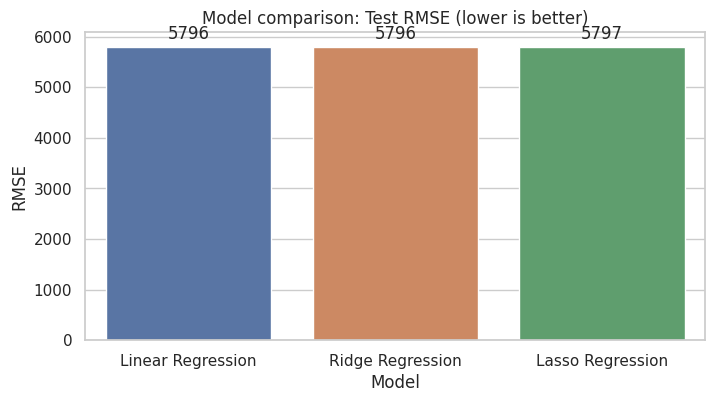

Best model (lowest test RMSE): Linear Regression


In [17]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=comparison, x="Model", y="RMSE", hue="Model", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Model comparison: Test RMSE (lower is better)")
plt.ylabel("RMSE")
plt.show()

# Map each model name to its fitted pipeline and chosen hyperparameter
fitted_models = {
    "Linear Regression": (lin_pipe, "None (no regularization)"),
    "Ridge Regression": (ridge_best, f"alpha = {ridge_grid.best_params_['model__alpha']}"),
    "Lasso Regression": (lasso_best, f"alpha = {lasso_grid.best_params_['model__alpha']}"),
}

best_model_name = comparison.loc[0, "Model"]
best_pipeline, best_hyperparameter = fitted_models[best_model_name]
best_metrics = comparison.loc[0]

print(f"Best model (lowest test RMSE): {best_model_name}")

## 13. Cross Validation
Cross-validation tests the model on different subsets of the training data to get a more reliable estimate of performance. With 5 folds, the training data is split into 5 parts; the model trains on 4 parts and is scored on the remaining part, and this repeats 5 times.

Below is the 5-fold cross-validation performance of the best model (on the **training** data only).

In [18]:
cv_rmse = -cross_val_score(clone(best_pipeline), X_train, y_train, cv=kf,
                           scoring="neg_root_mean_squared_error")
cv_r2 = cross_val_score(clone(best_pipeline), X_train, y_train, cv=kf, scoring="r2")

print(f"Model: {best_model_name}")
print(f"CV RMSE per fold: {np.round(cv_rmse, 2)}")
print(f"CV RMSE mean ± std: {cv_rmse.mean():,.2f} ± {cv_rmse.std():,.2f}")
print(f"CV R²   mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

Model: Linear Regression
CV RMSE per fold: [6602.04 6528.25 5437.13 6427.86 5621.49]
CV RMSE mean ± std: 6,123.35 ± 491.65
CV R²   mean ± std: 0.7389 ± 0.0311


## 14. Actual vs Predicted
For the best model, we plot the real charges against the predicted charges on the test set.

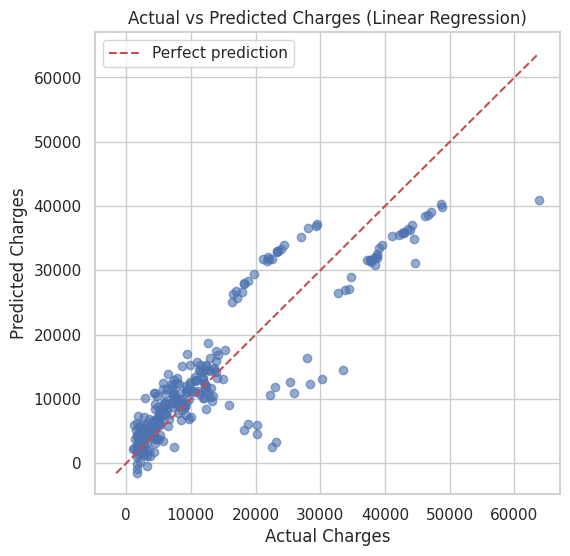

In [19]:
best_predictions = best_pipeline.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_predictions, alpha=0.6)
lims = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Actual vs Predicted Charges ({best_model_name})")
plt.legend()
plt.show()

**What does this plot tell us?**
Each dot is one person in the test set. If the model were perfect, every dot would lie exactly on the red diagonal line. Dots **close to the line** are good predictions; dots **far above or below** are large errors. Look for areas where the points drift systematically away from the line – that shows where a purely linear model struggles.

## 15. Residual Analysis
A **residual** is the prediction error for one person:

```
Residual = Actual - Predicted
```

A positive residual means the model **under-predicted**; a negative one means it **over-predicted**.

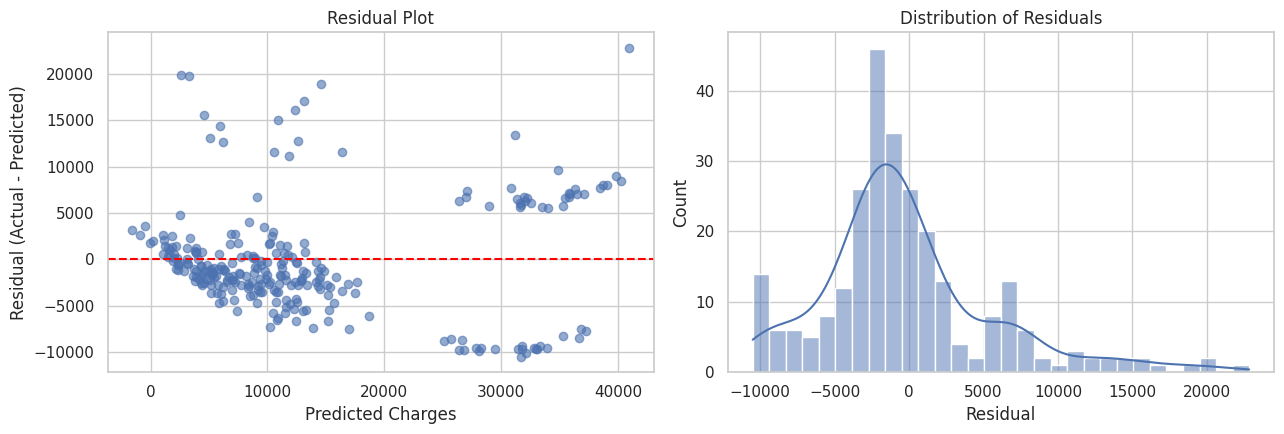

Mean residual: -219.24


In [20]:
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(best_predictions, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residual Plot")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():,.2f}")

**How to read the residual plot**
In a well-fitting linear model, residuals are scattered **randomly around zero** with no clear shape and a roughly constant spread. If you can see a **curve, a funnel shape, or separate clusters**, the model is missing some pattern in the data (for example, a non-linear effect or an interaction between features such as smoking and BMI). Check the plot above to judge whether the residuals look random or show structure – if they do not look random, that is a sign that more advanced feature engineering or non-linear models could help.

## 16. Feature Coefficients
A linear model learns **one coefficient per feature**. After `ColumnTransformer` and `OneHotEncoder`, the original categorical columns become several new columns (for example `smoker_yes`), so we extract the transformed feature names with `get_feature_names_out()`.

In [21]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[1] for name in feature_names]   # remove "num__" / "cat__" prefixes

coefficients = best_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
})
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False).reset_index(drop=True)

print(f"Model: {best_model_name}")
coef_df.head(10)

Model: Linear Regression


,Feature,Coefficient,Absolute_Coefficient
0,smoker_yes,11825.564428,11825.564428
1,smoker_no,-11825.564428,11825.564428
2,age,3614.975415,3614.975415
3,bmi,2036.228123,2036.228123
4,children,516.890247,516.890247
5,region_northeast,459.585244,459.585244
6,region_southwest,-350.214110,350.214110
7,region_southeast,-198.279052,198.279052
8,region_northwest,88.907918,88.907918
9,sex_female,9.295846,9.295846


**How to interpret the coefficients (simple English)**
- Numeric features were **standardised**, so their coefficient shows the change in predicted `charges` for a **1 standard-deviation increase** in that feature, keeping the others fixed.
- One-hot features (like `smoker_yes`) show the **difference in predicted charges** between that category and the other categories, keeping the others fixed.
- Because `OneHotEncoder` creates a column for *every* category (e.g. both `smoker_yes` and `smoker_no`), related columns can appear as mirrored pairs with similar sizes and opposite signs for plain Linear Regression. Read them as one comparison, not two separate effects.
- A **positive** coefficient pushes the prediction up; a **negative** one pushes it down. A larger absolute value means a stronger influence **on the model's predictions**.

⚠️ **These coefficients describe patterns the model learned, not proof of cause and effect.** Correlation does not prove causation – for example, the model cannot tell us that changing a feature would change a person's actual medical costs.

## 17. Final Results
All numbers below come from the models executed above, evaluated on the held-out test set.

In [22]:
print("=" * 45)
print("FINAL RESULTS")
print("=" * 45)
print(f"Best Model          : {best_model_name}")
print(f"Best Hyperparameter : {best_hyperparameter}")
print(f"MAE                 : {best_metrics['MAE']:,.2f}")
print(f"RMSE                : {best_metrics['RMSE']:,.2f}")
print(f"R²                  : {best_metrics['R²']:.4f}")
print("=" * 45)

FINAL RESULTS
Best Model          : Linear Regression
Best Hyperparameter : None (no regularization)
MAE                 : 4,181.19
RMSE                : 5,796.28
R²                  : 0.7836


## 18. Conclusion
The code cell below writes a short conclusion based on the **actual results** produced by this run.

In [23]:
lin_rmse = lin_metrics["RMSE"]
best_rmse = best_metrics["RMSE"]
best_reg_rmse = min(ridge_metrics["RMSE"], lasso_metrics["RMSE"])
improvement = lin_rmse - best_reg_rmse

print(f"1. Best performing model: {best_model_name} (hyperparameter: {best_hyperparameter}), with a test RMSE of {best_rmse:,.2f}.")

if best_model_name == "Linear Regression":
    print("2. Regularization did NOT clearly help here: plain Linear Regression had the lowest test RMSE.")
elif improvement > 0:
    print(f"2. Regularization helped slightly: the best regularized model lowered RMSE by {improvement:,.2f} versus plain Linear Regression.")
else:
    print("2. Regularization made little difference compared with plain Linear Regression.")

print(f"3. RMSE means that, on average, the predictions are off by roughly {best_rmse:,.0f} in insurance charges (large errors count more).")
print(f"4. R² of {best_metrics['R²']:.2f} means the model explains about {best_metrics['R²']*100:.0f}% of the variation in charges.")

1. Best performing model: Linear Regression (hyperparameter: None (no regularization)), with a test RMSE of 5,796.28.
2. Regularization did NOT clearly help here: plain Linear Regression had the lowest test RMSE.
3. RMSE means that, on average, the predictions are off by roughly 5,796 in insurance charges (large errors count more).
4. R² of 0.78 means the model explains about 78% of the variation in charges.


### Summary in plain English
- **Which model performed best?** See the output above – it is selected automatically by the lowest test RMSE.
- **Did regularization help?** Ridge and Lasso mainly help when a model overfits or features are highly correlated. This dataset is small with only a few features, so the three linear models usually perform very similarly.
- **What does RMSE mean?** It is the typical size of the prediction error, in the same unit as `charges`. Smaller is better.
- **What does R² mean?** It is the fraction of the variation in `charges` explained by the model. Closer to 1 is better.

### What could be improved?
- **Log-transform `charges`** to reduce the skew in the target.
- **Feature engineering**, e.g. an interaction between `smoker` and `bmi`, or squared `age`, so the linear model can capture non-linear effects.
- **Handle outliers**, since a few very expensive cases pull the model.
- Try **Elastic Net** (a mix of Ridge and Lasso) and a **larger hyperparameter search**.
- Compare with **non-linear models** to see how much a linear model leaves on the table.